<a href="https://colab.research.google.com/github/llllllrxx/GEOG761-labs/blob/main/761_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
The primary objective of this lab is to familiarise you with the basic mechanics that allow you to get hold of satellite data for the purposes of carrying out machine learning. The second objective is for you to put into practice some of the theory that we covered in lectures 1 and 2, in order that you can start to understand some of the specific quirks and potentially powerful attributes of satellite data when it comes to applying machine learning techniques.

This lab has drawn upon the following sources, tutorials and repos:


*   https://geemap.org/
*   https://developers.google.com/earth-engine

Whenever you see a numbered question, e.g. '(1)', make sure that you answer it in the answer proforma and submit the resulting document on Canvas. Only submit in .docx or .pdf formats (we cannot open 'pages' etc docs on Canvas).

If you want to submit code as your 'working' OR we ask you to give your code as part of the answer, give a link in your proforma document to a Colab notebook that is stored in a place we can access (your own GitHub account for example!).

Some of the questions will be relatively simple and are designed to get you thinking about the nature of the code and what it is doing, whilst also requiring you to pull in theoretical knowledge from the lectures. Other questions are exercises that ask you to both apply this knowledege to a new challenge and/or require you to independently go and seek answers.

In all cases I encourage you to give it a go, even if you do not have the full answer. Particularly for the larger challenges ('Exercises'), marks are awarded for workings and I want to see your thought process in action via the code you write.

Use text comments as demonstrated in these lab instructions to explain your thinking and communicate with the person marking your work.

I use both comments above chunks of code to tell you the overall objectives of that code, and inline comments to highlight specific features and elements to be aware of (formatted like this to draw your attention '#<-').

You are expected to present outputs to a professional standard. This means maps must have scales, north arrows and legends that are readable. For a good guide to all matters professional figure drawing, see this Nature guide:
*    https://research-figure-guide.nature.com/figures/preparing-figures-our-specifications/.

A portion of the marks are for presentation and communication.

# Set up

In [ ]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='my-project-761-503909')

In [ ]:
# Install the geemap package (only needs to be run once, uncomment below and run it the first time you run this notebook in a session).
# !pip install geemap

In [ ]:
import geemap

# Loading a map and displaying satellite data

In [ ]:
# Use the built in functions to load an ipyleaflet basemap (this is a UI to explore and see what we are doing)
# Note that I used to show you Open Street Map here, but there is currently a tile/scraper battle going on, and notebooks have been caught in the cross-fire.
Map = geemap.Map(center=(-41, 172), zoom=4, basemap="HYBRID")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [ ]:
# Specify a different kind of basemap to display data layers over
Map = geemap.Map(center=(-41, 172), zoom=4) #<- note the lat-lon coordinate pair here
Map.add_basemap("USGS.USImageryTopo")
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

(1) Find and add the basemap 'OpenTopoMap' to the display window AND change the code so that the map opens and zooms to the city of Auckland.
Provide a link to your code in a notebook and the output as a figure in the answer proforma. (2 pts)

In [ ]:
# Add Earth Engine datasets to our map by first creating variables to hold the calls to the EE api
Map = geemap.Map(center=(-41, 172), zoom=4)
dem = ee.Image("USGS/SRTMGL1_003")
landcover = ee.Image("ESA/GLOBCOVER_L4_200901_200912_V2_3").select("landcover")
landsat7 = ee.Image("LANDSAT/LE7_TOA_5YEAR/1999_2003")
states = ee.FeatureCollection("TIGER/2018/States")

In [ ]:
# Set visualization parameters.
vis_params = {
    "min": 0,
    "max": 4000, #<- if your satellite image is all white or all black, these vis params are the first thing to check and change
    "palette": ["006633", "E5FFCC", "662A00", "D8D8D8", "F5F5F5"], #<- these are HTML colour codes
}

In [ ]:
# Add a variety of different Earth Engine layers to the Map object
Map.addLayer(dem, vis_params, "SRTM DEM", True, 0.5) #<- note vis params called from the dictionary we set up before
Map.addLayer(landcover, {}, "Land cover")
Map.addLayer(
    landsat7, {"bands": ["B4", "B3", "B2"], "min": 20, "max": 200}, "Landsat 7" #<- note vis params in a dictionary here inside the add layer call
)
Map.addLayer(states, {}, "US States")

In [ ]:
# Dump all of this into the map view and take a look...
# Scroll around (look at both NZ and USA), check and uncheck the layers in the layer menu on the top-right.
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [ ]:
Map = geemap.Map(center=(-36.8485, 174.7633), zoom=11)
Map.add_basemap("OpenTopoMap")
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(2) The Landsat 7 data displays as red colored/tinged image. Why is this? [Think about both the content in Lecture 1, and what is going on when you visualize a satellite image]. (2 pts)

In the code, the band order is B4 (Near-Infrared) → B3 (Red) → B2 (Green), mapped to the display's R, G, B channels respectively. This is not true colour but a classic "false-colour / colour-infrared composite." Vegetation reflects strongly in the near-infrared band, and since NIR is mapped to the red display channel, vegetation-heavy areas like New Zealand appear bright red. This composite is a standard technique for assessing vegetation health.

(3) Correct the display of the Landsat 7 image so that it displays in '[True Colour](https://weather.ndc.nasa.gov/sport/training/quickGuides/rgb/QuickGuide_TrueColorRGB_NASA_SPoRT.pdf)'. Provide a notebook example of your code and the corrected output over the whole of New Zealand. (10 pts)

In [ ]:
Map = geemap.Map(center=(-41, 172), zoom=6)
Map.addLayer(
    landsat7,
    {"bands": ["B3", "B2", "B1"], "min": 20, "max": 200},
    "Landsat 7 True Colour"
)
Map

Map(center=[-41, 172], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

# Spectral reflectance curves
Next we we will generate a spectral reflectance curve for a given area.
This is a useful tool when you are considering if a given target has spectral characteristics for identification in ML. If everything has the same spectral signature, then you need to take a different approach to a simple spectral classification, as might have been the first instinct of a classical remote sensing scientist before the advent of machine learning.

In [ ]:
# Add in a library for plotting the data we extract
import matplotlib.pyplot as plt

In [ ]:
# Define a point and a small rectangular region around it
point = ee.Geometry.Point([174.7633, -36.8485])  # Auckland, NZ
region = point.buffer(150).bounds()  # ~300 m box

In [ ]:
# Load a Landsat 7 Collection 2 Level 2 SR image (surface reflectance)
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

(4) Why are we using the surface reflectance (SR) here rather than the top of atmosphere (ToA)? (2 pt)

ToA (Top-of-Atmosphere) reflectance is the radiance measured directly by the sensor, which includes interference from atmospheric scattering, absorption, aerosols, and water vapour. SR (Surface Reflectance) has been atmospherically corrected to remove these effects, better representing the true reflectance of the ground surface. For machine learning and time-series analysis, what matters is the spectral signature of the land cover itself, not a mixed atmosphere-plus-surface signal. Using SR gives better comparability and consistency across images captured at different times and under different atmospheric conditions, reducing spurious features introduced by atmospheric noise.

In [ ]:
# Select surface reflectance bands and apply scale factor
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}

scale_factor = 2.75e-5  # From USGS documentation for Landsat C2 L2

(5) What is a 'scale factor' as has been used in the prior code cell, and why are they used in satellite data storage-to-processing workflows such as this? (2 pts)

A scale factor is a multiplier used to convert stored integer raw values (digital numbers, DN) back into physically meaningful continuous quantities (e.g., reflectance between 0–1). This is used because satellite data volumes are enormous — storing continuous physical quantities directly as floating-point numbers would substantially increase storage and transmission costs. Storing data as integers (typically 16-bit) instead significantly compresses data size and speeds up processing. Multiplying by the known scale factor after reading recovers the true physical value. This is an engineering trade-off between storage efficiency and physical precision.

**Important sidenote**

The 'reduce' operation is a key concept in the backend of how Google is storing and serving us large quanities of satellite data. GEE uses 'reducers' in multiple ways, many of which are not always immediately intuitive. Check out the docs for more information:

*   https://developers.google.com/earth-engine/guides/reducers_intro

Here we are using a reduce operation over the specified small sample area in order to find the mean of all the cells that lie within the region:

In [ ]:
# Reduce region to mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6
)

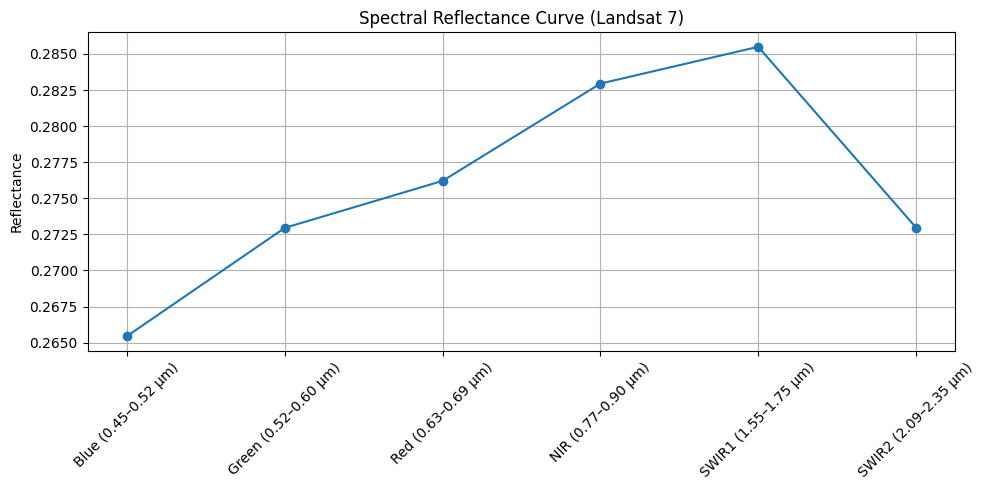

In [ ]:
# Extract and scale values
mean_values = mean_dict.getInfo()
reflectance = [mean_values[b] * scale_factor for b in bands]

# Plot the spectral curve
plt.figure(figsize=(10, 5))
plt.plot(list(band_names.values()), reflectance, marker='o', linestyle='-')
plt.title('Spectral Reflectance Curve (Landsat 7)')
plt.ylabel('Reflectance')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

(6) If we want to apply multiple reducers to the same inputs what is a more efficient way to do so than just writing out a long series of sequential reducers on our end? (2 pts)

In [ ]:
combined_reducer = ee.Reducer.mean().combine(
    reducer2=ee.Reducer.stdDev(),
    sharedInputs=True
)

stats = image.select(bands).reduceRegion(
    reducer=combined_reducer,
    geometry=region,
    scale=30,
    maxPixels=1e6
).getInfo()

print(stats)

{'SR_B1_mean': 9652.664958006388, 'SR_B1_stdDev': 1049.8777398349682, 'SR_B2_mean': 9925.442569299315, 'SR_B2_stdDev': 1152.818261097469, 'SR_B3_mean': 10043.854855881073, 'SR_B3_stdDev': 1268.4256018376861, 'SR_B4_mean': 10288.878001656085, 'SR_B4_stdDev': 1248.7557367132058, 'SR_B5_mean': 10381.604077126296, 'SR_B5_stdDev': 1546.8828366098776, 'SR_B7_mean': 9926.202633965539, 'SR_B7_stdDev': 1398.329135206627}


Instead of calling reduceRegion multiple times in sequence (which re-scans the pixels each time), use .combine() to merge multiple reducers into a single composite reducer that computes several statistics in one pass. This avoids repeatedly scanning the same pixels on the GEE server side and reduces the number of .getInfo() network round-trips.

# Cloud cover
A final consideration that I want to cover in this lab is that of cloud cover. Cloud cover removal is a complex and often difficut process that GISCI 341 students spend an entire two weeks tackling as a focus (so use them in your teams!). However, for our purpose here lets just use the basic in-built cloud clearing native to the Landsat 7 collection on GEE.

In [ ]:
# Define small region around Auckland, NZ
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(500).bounds()

# Load the image with least cloud cover in 2002
image = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2") \
    .filterBounds(region) \
    .filterDate("2002-01-01", "2002-12-31") \
    .sort("CLOUD_COVER") \
    .first() #<- note the filtering step that is being applied here! We are taking the first image in a sorted by cloud cover response.

# Check metadata
print('Image ID:', image.get('LANDSAT_PRODUCT_ID').getInfo())
print('Cloud Cover (whole scene):', image.get('CLOUD_COVER').getInfo())

Image ID: LE07_L2SP_073086_20020827_20200916_02_T1
Cloud Cover (whole scene): 1


In [ ]:
# Function to mask clouds using QA_PIXEL band
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 and 4 are cloud and cloud shadow respectively
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(
                 qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

# Apply mask
masked_image = mask_clouds(image)

**Important side note**

In the function above we are using a bitwise operation in order to search through the quality assurance (QA) band of the image. Different satellites have different bit-masks. Read more about bitmasks and how they are used here:
*   https://spatialthoughts.com/2021/08/19/qa-bands-bitmasks-gee/



**Another important side note**

You will have noticed that we are frequently running code and not seeing anything happen in terms of output in the cell or changes in the RAM/Disk of the Colab instance (check the small graphs top right). This is deliberate! Satellite data is large and hard to wrangle. GEE does a lot of the work for us, hence we can explore and get into it so quickly. Part of how it does this is by not executing any of your API calls until you specifically ask for an output to be sent back to you. Prior to calling an output (usually through a 'AddLayer' or similar call), when using the GEE/EE API you are essentially chaining together a lot of dot-operators (e.g. '.sort \ .reduce') into a series of instructions that are verified, but only then acted on when required.

This is the result of a 'client vs. server' approach. For more detail, that will help you understand why you can and cannot do certain things, see:
*   https://developers.google.com/earth-engine/guides/client_server



In [ ]:
# Report Image Quality Over ROI
# Total pixels in region
pixel_area = ee.Image.pixelArea().clip(region)

# Count valid pixels before and after masking
total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['area']

valid_pixels = masked_image.select('SR_B3').reduceRegion(
    reducer=ee.Reducer.count(),
    geometry=region,
    scale=30,
    maxPixels=1e9
).getInfo()['SR_B3']

cloud_coverage_pct = 100 * (1 - valid_pixels / total_pixels)

print(f"Total Pixels: {total_pixels}")
print(f"Valid (non-cloud) Pixels: {valid_pixels}")
print(f"Estimated Cloud Coverage in ROI: {cloud_coverage_pct:.2f}%")

Total Pixels: 1394
Valid (non-cloud) Pixels: 1050
Estimated Cloud Coverage in ROI: 24.68%


In [ ]:
# Visualize the before and after
Map = geemap.Map(center=[-36.8485, 174.7633], zoom=12)

vis = {
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}

Map.addLayer(image, vis, 'Original Image (Cloudy)')
Map.addLayer(masked_image, vis, 'Cloud Masked')
Map

Map(center=[-36.8485, 174.7633], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

(7) Produce a table that tells me the average amount of cloud cover per LandSat image in a year: for 2005, 2010 and 2015. Do this over a region of your choice, as a percentage.

Provide a notebook example of your code that does so, in addition to your table. (5 pts)

In [ ]:
import ee
import pandas as pd

# ee.Initialize(project='earthengine-ml-testing')

region = ee.Geometry.Point([174.7633, -36.8485]).buffer(5000).bounds()

years = [2005, 2010, 2015]
rows = []

for year in years:
    coll = (ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")
            .filterBounds(region)
            .filterDate(f"{year}-01-01", f"{year}-12-31"))

    n_images = coll.size().getInfo()

    if n_images == 0:
        mean_cloud = None
    else:
        mean_cloud = coll.aggregate_mean("CLOUD_COVER").getInfo()

    rows.append({
        "Year": year,
        "N Images": n_images,
        "Mean Cloud Cover (%)": round(mean_cloud, 2) if mean_cloud is not None else "N/A"
    })

cloud_table = pd.DataFrame(rows)
print(cloud_table)

   Year  N Images  Mean Cloud Cover (%)
0  2005        55                 46.29
1  2010        59                 43.69
2  2015        60                 48.75


This uses the image's built-in scene-level CLOUD_COVER metadata property, aggregated server-side with aggregate_mean(), avoiding the need to download each image or run pixel-level cloud masking — much more efficient and concise. Note that CLOUD_COVER is a whole-scene estimate, not the cloud percentage strictly within your region of interest; if a stricter region-level percentage is required, you'd need the pixel-level masking + reduceRegion counting approach demonstrated earlier in the "Cloud cover" section, looped over every image per year — much more computationally expensive.

# Final exercise
Let us now be very fancy and plot our spectral reflectance curve along with a display of the satellite data that it was generated from. As well as being fancy, this lets us see that what we have done here is sample the urban fabric of downtown Auckland and collect the spectral signature of 'urban'.

The code block below is large and calls in some further packages as we start to push beyond what is already built into geemap. I have also placed all the required code in one cell as I am about to ask you to do something with it... Make sure that you take the time understand what each section is doing and why. Consider starting to break this code down into functions that you can re-use later. If you do not know what I mean by this, please ask! (And Google 'modular code design, functions').

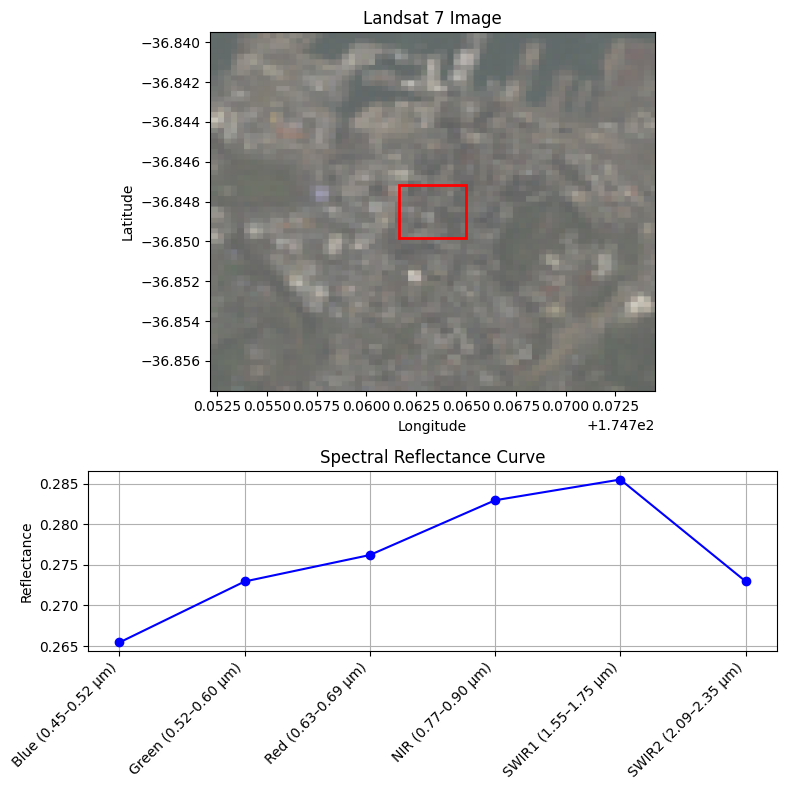

In [ ]:
# Additional required packages
import matplotlib.patches as patches
import urllib.request
import tempfile
import matplotlib.image as mpimg

# Define point and regions
point = ee.Geometry.Point([174.7633, -36.8485])
region = point.buffer(150).bounds()        # ~300 m box
expanded_region = point.buffer(1000).bounds()  # box for image preview

# Load Landsat 7 surface reflectance image
image = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filterBounds(region) \
    .filterDate('2002-01-01', '2002-12-31') \
    .sort('CLOUD_COVER') \
    .first()

# Define bands and scaling
bands = ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7']
band_names = {
    'SR_B1': 'Blue (0.45–0.52 μm)',
    'SR_B2': 'Green (0.52–0.60 μm)',
    'SR_B3': 'Red (0.63–0.69 μm)',
    'SR_B4': 'NIR (0.77–0.90 μm)',
    'SR_B5': 'SWIR1 (1.55–1.75 μm)',
    'SR_B7': 'SWIR2 (2.09–2.35 μm)'
}
scale_factor = 2.75e-5

# Calculate mean reflectance
mean_dict = image.select(bands).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=region,
    scale=30,
    maxPixels=1e6).getInfo()

reflectance = [mean_dict[b] * scale_factor for b in bands]
labels = list(band_names.values())

# Get RGB thumbnail slightly zoomed out
thumb_params = {
    'dimensions': 512,
    'region': expanded_region,
    'format': 'png',
    'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
    'min': 0,
    'max': 30000,
    'gamma': 1.4
}
url = image.getThumbURL(thumb_params)

# Get coordinates of regions
def get_bounds_coords(bounds):
    coords = bounds.coordinates().getInfo()[0]
    lons = [pt[0] for pt in coords]
    lats = [pt[1] for pt in coords]
    return min(lons), max(lons), min(lats), max(lats)

# Extract bounding boxes
xmin, xmax, ymin, ymax = get_bounds_coords(expanded_region)
rxmin, rxmax, rymin, rymax = get_bounds_coords(region)

# Plot both panels
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [2, 1]})

# Load and plot image with annotation
with tempfile.NamedTemporaryFile(suffix=".png") as f:
    urllib.request.urlretrieve(url, f.name)
    img = mpimg.imread(f.name)
    ax1.imshow(img, extent=[xmin, xmax, ymin, ymax])
    ax1.set_title("Landsat 7 Image")
    ax1.set_xlim(xmin, xmax)
    ax1.set_ylim(ymin, ymax)

    # Add red rectangle for region of interest
    width = rxmax - rxmin
    height = rymax - rymin
    rect = patches.Rectangle((rxmin, rymin), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")

# Plot reflectance
ax2.plot(labels, reflectance, marker='o', color='blue')
ax2.set_title("Spectral Reflectance Curve")
ax2.set_ylabel("Reflectance")
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.grid(True)

plt.tight_layout()
plt.show()


(8) Exercise: Using Sentinel 2, create a figure that does the following over the city of Christchurch, NZ:
*   Conduct a basic quality assessment of the data you use by stating how much of your area is covered by cloud.
* Show the spectral reflectance signatures of: urban, forest, grassland, water and bare soil. Using a line graph that stacks them all onto the same axes.
* Gives examples of the sample areas that you have used to create these spectral signatures.

Provide a publication quality copy of this figure in the answer proforma. Publication quality means that:  
1.   It is at a good quality (resolution) and not blurry.
2.   The font size of all elements is big enough to read easily on a screen when placed in the document.
3. Has a figure caption that ensures the reader knows what you have done and why.
4. Tells the story 'at a glance'. Don't make your viewer work too hard to understand your core message.

See the Nature guide linked at the start of this lab for more detail on what I expect.

(25 pts)




In [ ]:
import ee
import matplotlib.pyplot as plt

region = ee.Geometry.Point([172.6362, -43.5321]).buffer(10000).bounds()  # Christchurch

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(region)
      .filterDate("2023-01-01", "2023-03-31")
      .sort("CLOUDY_PIXEL_PERCENTAGE")
      .first())

print("Image date:", s2.date().format("YYYY-MM-dd").getInfo())
print("Scene cloud cover (metadata):", s2.get("CLOUDY_PIXEL_PERCENTAGE").getInfo())

def mask_s2_clouds(image):
    scl = image.select("SCL")
    # SCL: 3=cloud shadow, 8=cloud medium probability, 9=cloud high probability, 10=cirrus
    cloud_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(cloud_mask)

masked_s2 = mask_s2_clouds(s2)

# --- Region-level cloud cover assessment (required by the question) ---
pixel_area = ee.Image.pixelArea().clip(region)

total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(), geometry=region, scale=20, maxPixels=1e9
).getInfo()["area"]

valid_pixels = masked_s2.select("B4").reduceRegion(
    reducer=ee.Reducer.count(), geometry=region, scale=20, maxPixels=1e9
).getInfo()["B4"]

cloud_pct = 100 * (1 - valid_pixels / total_pixels)
print(f"Estimated cloud cover in ROI: {cloud_pct:.2f}%")

Image date: 2023-01-18
Scene cloud cover (metadata): 4.039137
Estimated cloud cover in ROI: 42.04%


Define sample points

In [ ]:
sample_points = {
    "Urban":     ee.Geometry.Point([172.6362, -43.5321]),  # Christchurch CBD
    "Forest":    ee.Geometry.Point([172.5850, -43.6100]),  # near Port Hills / Victoria Park bush
    "Grassland": ee.Geometry.Point([172.3500, -43.4700]),  # rural pastureland outside the city
    "Water":     ee.Geometry.Point([172.7350, -43.5590]),  # Avon-Heathcote Estuary
    "Bare soil": ee.Geometry.Point([172.4200, -43.5900]),  # fallow farmland / bare ground
}

Verify on the map first (this step should not be skipped — the coordinates above are rough estimates and are not guaranteed to hit the intended land cover):

In [ ]:
Map = geemap.Map(center=[-43.5321, 172.6362], zoom=11)
Map.addLayer(masked_s2, {
    "bands": ["B4", "B3", "B2"], "min": 0, "max": 3000, "gamma": 1.2
}, "Sentinel-2 True Colour")

for label, pt in sample_points.items():
    Map.addLayer(pt, {"color": "red"}, label)

Map

Map(center=[-43.5321, 172.6362], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

Extract spectral curves for all five classes and plot

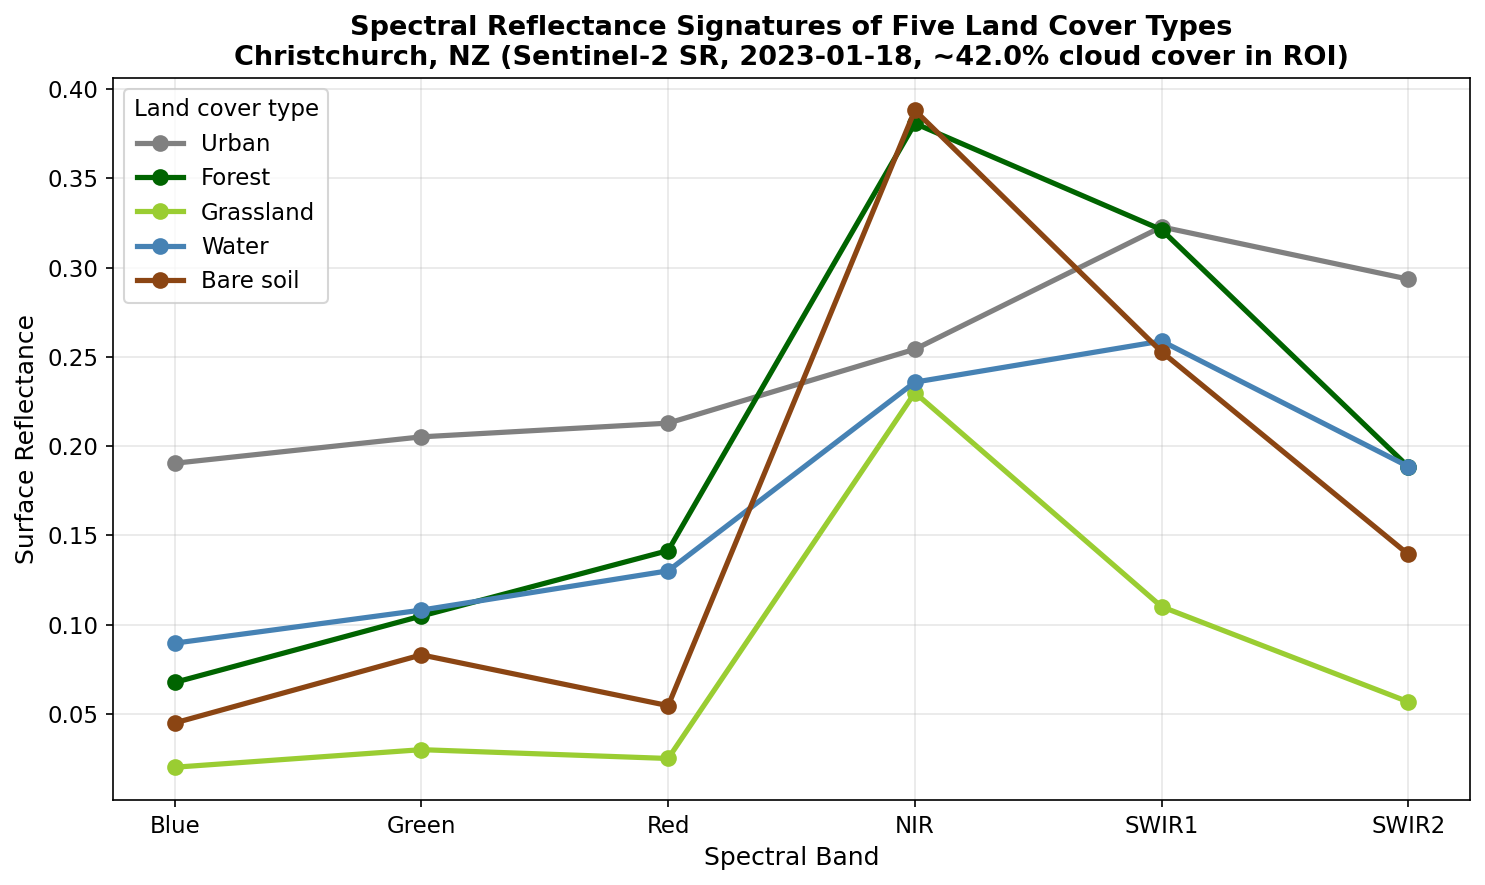

In [ ]:
bands = ["B2", "B3", "B4", "B8", "B11", "B12"]
wavelengths = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
scale_factor = 1e-4  # standard scale factor for Sentinel-2 SR harmonized data

spectral_data = {}

for label, pt in sample_points.items():
    buf = pt.buffer(30).bounds()
    vals = masked_s2.select(bands).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=buf,
        scale=10,       # B11/B12 are natively 20m; GEE resamples automatically to this scale
        maxPixels=1e6
    ).getInfo()
    reflectance = [vals[b] * scale_factor for b in bands]
    spectral_data[label] = reflectance

# --- Plot (publication quality) ---
plt.figure(figsize=(10, 6), dpi=150)

colors = {"Urban": "gray", "Forest": "darkgreen", "Grassland": "yellowgreen",
          "Water": "steelblue", "Bare soil": "saddlebrown"}

for label, reflectance in spectral_data.items():
    plt.plot(wavelengths, reflectance, marker="o", linewidth=2.5,
              markersize=7, label=label, color=colors.get(label))

plt.title(f"Spectral Reflectance Signatures of Five Land Cover Types\nChristchurch, NZ "
          f"(Sentinel-2 SR, {s2.date().format('YYYY-MM-dd').getInfo()}, "
          f"~{cloud_pct:.1f}% cloud cover in ROI)", fontsize=13, fontweight="bold")
plt.xlabel("Spectral Band", fontsize=12)
plt.ylabel("Surface Reflectance", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(fontsize=11, title="Land cover type", title_fontsize=11, loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("spectral_signatures_christchurch.png", dpi=300, bbox_inches="tight")
plt.show()

Sample area location map (explicitly required by the question)

In [ ]:
Map2 = geemap.Map(center=[-43.5321, 172.6362], zoom=10)
Map2.addLayer(masked_s2, {
    "bands": ["B4", "B3", "B2"], "min": 0, "max": 3000, "gamma": 1.2
}, "Sentinel-2 True Colour")

for label, pt in sample_points.items():
    buf = pt.buffer(30)
    Map2.addLayer(buf, {"color": colors.get(label)}, f"Sample: {label}")

Map2.add_legend(title="Sample Locations", legend_dict=colors)
Map2

Map(center=[-43.5321, 172.6362], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

Export a screenshot (or use Map2.to_image()) of this map alongside the spectral curve plot from Step 3 — place both figures in the proforma with a shared caption.

云覆盖率: 27.5%  影像日期: 2023-04-28


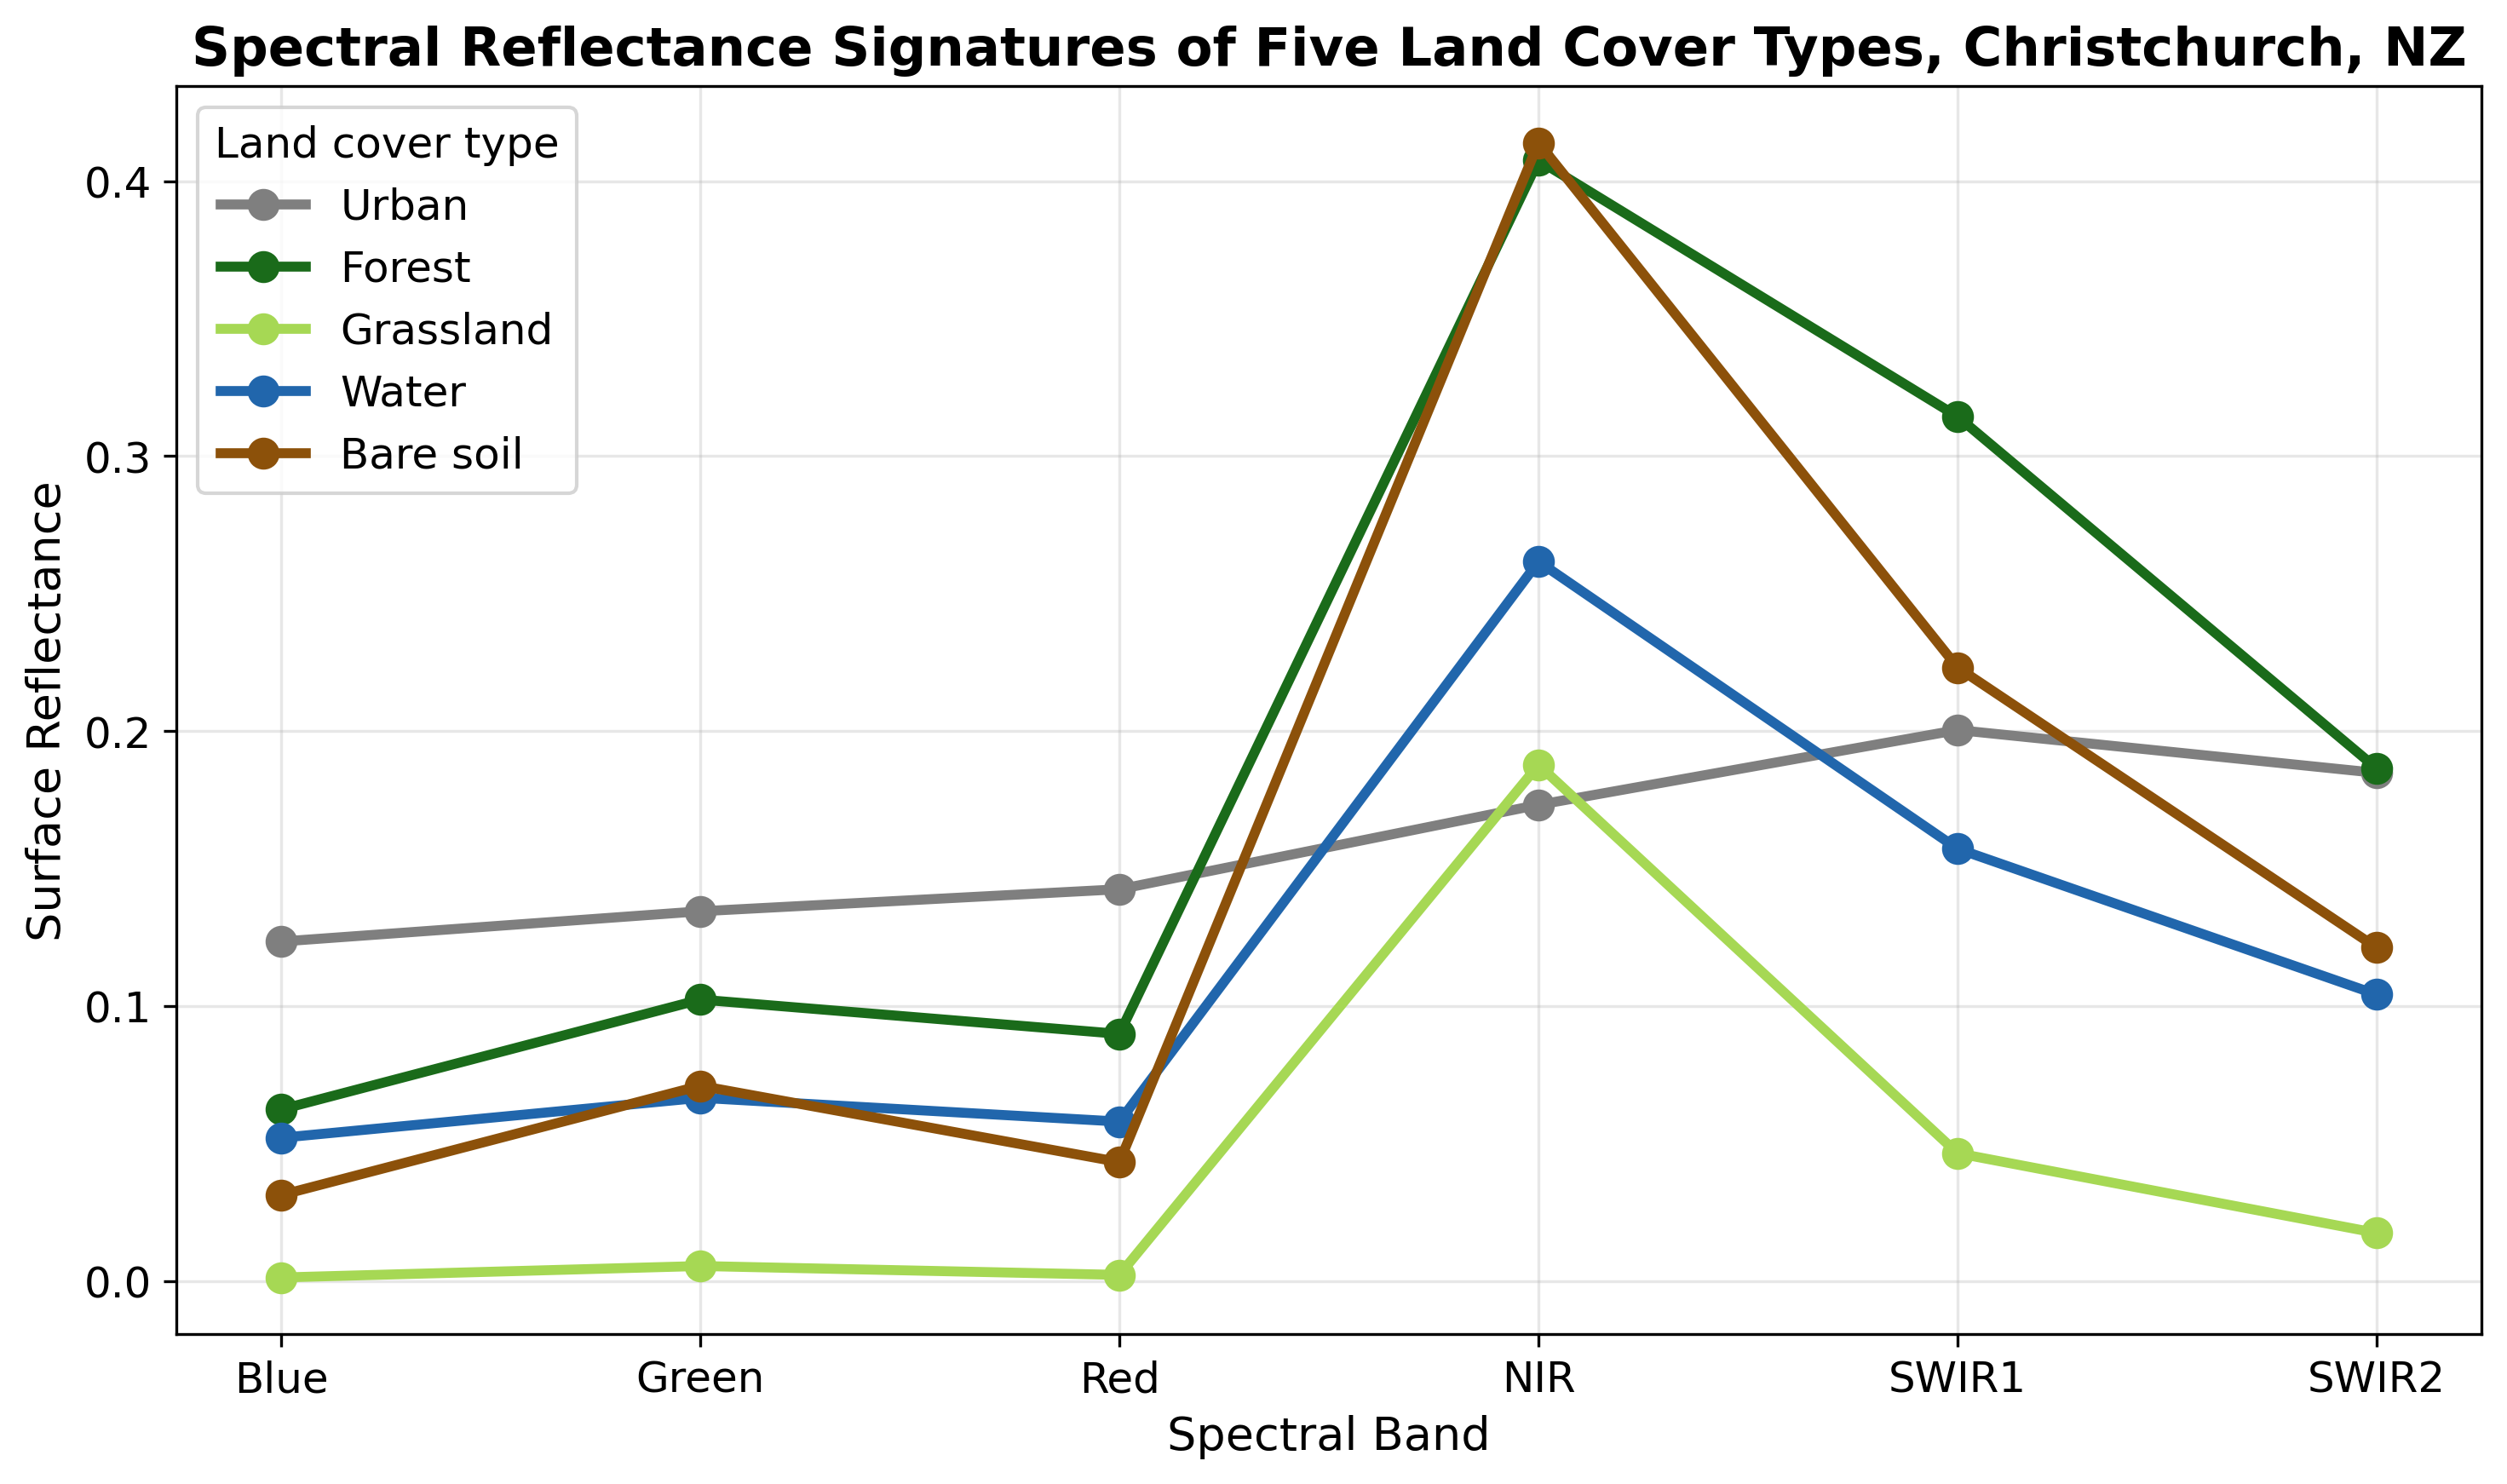

Map(center=[-43.5321, 172.6362], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

In [ ]:
import ee
import matplotlib.pyplot as plt

region = ee.Geometry.Point([172.6362, -43.5321]).buffer(10000).bounds()

# 放宽日期范围,尝试找到云量更低的影像
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(region)
      .filterDate("2023-01-01", "2023-06-30")   # 放宽到半年
      .sort("CLOUDY_PIXEL_PERCENTAGE")
      .first())

img_date = s2.date().format("YYYY-MM-dd").getInfo()

def mask_s2_clouds(image):
    scl = image.select("SCL")
    cloud_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(cloud_mask)

masked_s2 = mask_s2_clouds(s2)

pixel_area = ee.Image.pixelArea().clip(region)
total_pixels = pixel_area.reduceRegion(
    reducer=ee.Reducer.count(), geometry=region, scale=20, maxPixels=1e9
).getInfo()["area"]
valid_pixels = masked_s2.select("B4").reduceRegion(
    reducer=ee.Reducer.count(), geometry=region, scale=20, maxPixels=1e9
).getInfo()["B4"]
cloud_pct = 100 * (1 - valid_pixels / total_pixels)
print(f"云覆盖率: {cloud_pct:.1f}%  影像日期: {img_date}")

sample_points = {
    "Urban":     ee.Geometry.Point([172.6362, -43.5321]),
    "Forest":    ee.Geometry.Point([172.5850, -43.6100]),
    "Grassland": ee.Geometry.Point([172.3500, -43.4700]),
    "Water":     ee.Geometry.Point([172.7350, -43.5590]),
    "Bare soil": ee.Geometry.Point([172.4200, -43.5900]),
}

colors = {"Urban": "#7f7f7f", "Forest": "#1a6b1a", "Grassland": "#a6d854",
          "Water": "#2166ac", "Bare soil": "#8c510a"}

# --- 先逐点检查是否落在影像有效范围内,避免Grassland点采不到数据 ---
bands = ["B2", "B3", "B4", "B8", "B11", "B12"]
wavelengths = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
scale_factor = 1e-4

spectral_data = {}
valid_sample_points = {}
for label, pt in sample_points.items():
    buf = pt.buffer(30).bounds()
    vals = masked_s2.select(bands).reduceRegion(
        reducer=ee.Reducer.mean(), geometry=buf, scale=10, maxPixels=1e6
    ).getInfo()
    if all(vals.get(b) is not None for b in bands):
        spectral_data[label] = [vals[b] * scale_factor for b in bands]
        valid_sample_points[label] = pt
    else:
        print(f"⚠️ 警告: {label} 采样点在当前影像范围内无有效数据,请检查坐标是否落在影像覆盖区外")

# --- 图A:光谱曲线(更大字号 + 更高对比度配色 + 更清晰图例) ---
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

for label, reflectance in spectral_data.items():
    ax.plot(wavelengths, reflectance, marker="o", linewidth=2.8,
            markersize=8, label=label, color=colors[label])

ax.set_title("Spectral Reflectance Signatures of Five Land Cover Types, Christchurch, NZ",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Spectral Band", fontsize=13)
ax.set_ylabel("Surface Reflectance", fontsize=13)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, title="Land cover type", title_fontsize=12, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("spectral_signatures_christchurch.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 图B:采样区域位置图(近景 + 按类型着色 + 图例) ---
Map = geemap.Map(center=[-43.5321, 172.6362], zoom=11)
Map.addLayer(masked_s2, {
    "bands": ["B4", "B3", "B2"], "min": 0, "max": 3000, "gamma": 1.2
}, "Sentinel-2 True Colour")

for label, pt in valid_sample_points.items():
    buf = pt.buffer(120)  # 适当放大缓冲区,让点在这个缩放级别下肉眼可见
    Map.addLayer(buf, {"color": colors[label]}, f"Sample: {label}")

Map.add_legend(title="Sample Locations", legend_dict=colors)
Map  # 在浏览器里等所有图层完全加载(瓦片不再闪烁)后再用 Map.to_image() 或截图工具导出